# Variante RNN — Alan Osorio

Entrenamiento del `CharRNN(cell_type='rnn')` para generar nombres de dinosaurios.

Reutiliza el núcleo compartido en [src/](../src/): `dataset.py`, `model.py`, `train.py`, `sample.py`.

**Hiperparámetros**: `embed_dim=32`, `hidden_dim=128`, `num_layers=1`, `lr=1e-3`, `batch_size=64`, `patience=5`.

Ejecuta este notebook desde la **raíz del repo** (no desde `notebooks/`) para que los imports relativos funcionen.

In [1]:
import sys, os
from pathlib import Path

REPO_ROOT = Path.cwd()
while REPO_ROOT.name and not (REPO_ROOT / 'CLAUDE.md').exists():
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))
print('cwd:', os.getcwd())

cwd: /home/ec2-user/SageMaker


In [2]:
import torch
import matplotlib.pyplot as plt
import math
from Parte_1_Generador_Caracteres.src.dataset import make_dataloaders, load_names
from Parte_1_Generador_Caracteres.src.model import CharRNN
from Parte_1_Generador_Caracteres.src.sample import load_model, generate_unique

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


device: cpu


## 1. Datos

In [3]:
names = load_names('data/dinos.csv')
print(f'total nombres: {len(names)}')
print(f'longitud min/max: {min(map(len, names))}/{max(map(len, names))}')
print('ejemplos:', names[:5])

total nombres: 1536
longitud min/max: 3/26
ejemplos: ['aachenosaurus', 'aardonyx', 'abdallahsaurus', 'abelisaurus', 'abrictosaurus']


In [4]:
train_loader, val_loader, vocab, max_len = make_dataloaders('data/dinos.csv', batch_size=64)
print(f'vocab_size={len(vocab)}, max_len={max_len}')
print(f'train batches={len(train_loader)}, val batches={len(val_loader)}')

vocab_size=29, max_len=28
train batches=22, val batches=3


## 2. Entrenamiento

Llamamos directamente a `train.train(args)` para reutilizar el bucle del módulo compartido.
MLflow registra el experimento con `run_name="RNN_AlanOsorio"`.

In [5]:
from argparse import Namespace
from Parte_1_Generador_Caracteres.src.train import train

args = Namespace(
    data='data/dinos.csv',
    cell='rnn',
    epochs=50,
    batch_size=64,
    embed=32,
    hidden=128,
    layers=1,
    lr=1e-3,
    patience=5,
    checkpoint='Parte_1_Generador_Caracteres/models/rnn_AlanOsorio.pt',
    run_tag='AlanOsorio',
)
history, best_val = train(args)
print(f'\nbest val loss: {best_val:.4f}')
print(f'perplexity:   {math.exp(best_val):.2f}')

[train] device=cpu, cell=rnn


/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


epoch 01 | train 2.8677 | val 2.3585
epoch 02 | train 2.2666 | val 2.0794
epoch 03 | train 2.0834 | val 1.9549
epoch 04 | train 1.9848 | val 1.8849
epoch 05 | train 1.9237 | val 1.8360
epoch 06 | train 1.8833 | val 1.8003
epoch 07 | train 1.8486 | val 1.7688
epoch 08 | train 1.8184 | val 1.7518
epoch 09 | train 1.7914 | val 1.7182
epoch 10 | train 1.7679 | val 1.7005
epoch 11 | train 1.7482 | val 1.6811
epoch 12 | train 1.7302 | val 1.6635
epoch 13 | train 1.7125 | val 1.6484
epoch 14 | train 1.6983 | val 1.6307
epoch 15 | train 1.6850 | val 1.6245
epoch 16 | train 1.6715 | val 1.6107
epoch 17 | train 1.6577 | val 1.6042
epoch 18 | train 1.6460 | val 1.5930
epoch 19 | train 1.6342 | val 1.5841
epoch 20 | train 1.6242 | val 1.5765
epoch 21 | train 1.6106 | val 1.5716
epoch 22 | train 1.6019 | val 1.5668
epoch 23 | train 1.5913 | val 1.5530
epoch 24 | train 1.5807 | val 1.5501
epoch 25 | train 1.5723 | val 1.5436
epoch 26 | train 1.5635 | val 1.5406
epoch 27 | train 1.5547 | val 1.5386
e

## 3. Curvas de aprendizaje

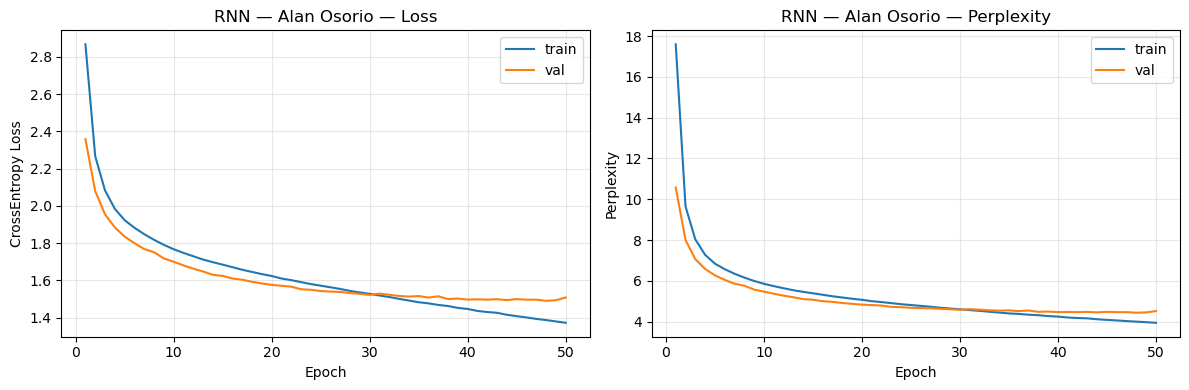

Gráfica guardada en reports/learning_curves_rnn.png


In [6]:
epochs_ran = list(range(1, len(history['train_loss']) + 1))
train_ppl = [math.exp(l) for l in history['train_loss']]
val_ppl   = [math.exp(l) for l in history['val_loss']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_ran, history['train_loss'], label='train')
axes[0].plot(epochs_ran, history['val_loss'],   label='val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CrossEntropy Loss')
axes[0].set_title('RNN — Alan Osorio — Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, train_ppl, label='train')
axes[1].plot(epochs_ran, val_ppl,   label='val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexity')
axes[1].set_title('RNN — Alan Osorio — Perplexity'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig('reports/learning_curves_rnn.png', dpi=120, bbox_inches='tight')
plt.show()
print('Gráfica guardada en reports/learning_curves_rnn.png')

## 4. Métricas finales

In [7]:
best_train = min(history['train_loss'])
print(f'Épocas entrenadas : {len(epochs_ran)}')
print(f'Mejor train loss  : {best_train:.4f}  (ppl = {math.exp(best_train):.2f})')
print(f'Mejor val loss    : {best_val:.4f}  (ppl = {math.exp(best_val):.2f})')

Épocas entrenadas : 50
Mejor train loss  : 1.3730  (ppl = 3.95)
Mejor val loss    : 1.4908  (ppl = 4.44)


## 5. Muestreo — 5 nombres de muestra

Sanity check visual con `temperature=1.0, top_p=0.9`, excluyendo los nombres ya existentes en `dinos.csv`.

In [8]:
model_rnn, vocab_rnn, max_len_rnn = load_model(args.checkpoint, device=device)
seen = set(load_names('data/dinos.csv'))

sample_names = generate_unique(
    model_rnn, vocab_rnn, max_len_rnn,
    n=5,
    temperature=1.0,
    top_k=None,
    top_p=0.9,
    seen=seen,
    device=device,
)

print('5 nombres generados por la RNN (temperature=1.0, top_p=0.9):')
for name in sample_names:
    print(f'  → {name}')

5 nombres generados por la RNN (temperature=1.0, top_p=0.9):
  → lerocophorosaurus
  → datansaurus
  → peotoronius
  → alaphacondeosaurus
  → palamosaurus


## 6. Barrido de parámetros de muestreo

Probamos las combinaciones del enunciado. El CSV completo se guarda en `data/generated/names_rnn.csv`.

In [9]:
import itertools, csv
from pathlib import Path

temperatures = [0.7, 1.0, 2.5, 4.0]
top_ks       = [None, 5, 10]
top_ps       = [None, 0.9, 0.95]

rows = []
for temp, tk, tp in itertools.product(temperatures, top_ks, top_ps):
    batch = generate_unique(
        model_rnn, vocab_rnn, max_len_rnn,
        n=3, temperature=temp, top_k=tk, top_p=tp,
        seen=seen, device=device,
    )
    for name in batch:
        rows.append({'temperature': temp, 'top_k': tk, 'top_p': tp, 'name': name})

out_dir = Path('data/generated')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'names_rnn.csv'

with open(out_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['temperature', 'top_k', 'top_p', 'name'])
    writer.writeheader()
    writer.writerows(rows)

print(f'Guardados {len(rows)} nombres en {out_path}')

Guardados 108 nombres en data/generated/names_rnn.csv


## 7. Promoción a `best_model.pt` (si gana)

Comparar `best_val` con el de Juan Camilo (LSTM, `02_lstm_JuanCamiloGallardo.ipynb`) y Santiago (GRU, `02_gru_SantiagoDiaz.ipynb`). Si la RNN tiene el val loss más bajo, promocionar:

```python
import shutil
shutil.copy(args.checkpoint, 'Parte_1_Generador_Caracteres/models/best_model.pt')
print('RNN promovida a best_model.pt')
```

**Coordinar con el equipo antes de ejecutar** — el checkpoint final lo consume el API en SageMaker (Parte 2) y el frontend (Parte 4).